# 2.6 Probability and Statistics

From [Dive into Deep Learning - Probability and Statistics](https://d2l.ai/chapter_preliminaries/probability.html)

One way or another,
machine learning is all about uncertainty.
In supervised learning, we want to predict
something unknown (the *target*)
given something known (the *features*).
Depending on our objective,
we might attempt to predict
the most likely value of the target.
Or we might predict the value with the smallest
expected distance from the target.
And sometimes we wish not only
to predict a specific value
but to *quantify our uncertainty*.
For example, given some features
describing a patient,
we might want to know *how likely* they are
to suffer a heart attack in the next year.
In unsupervised learning,
we often care about uncertainty.
To determine whether a set of measurements are anomalous,
it helps to know how likely one is
to observe values in a population of interest.
Furthermore, in reinforcement learning,
we wish to develop agents
that act intelligently in various environments.
This requires reasoning about
how an environment might be expected to change
and what rewards one might expect to encounter
in response to each of the available actions.

*Probability* is the mathematical field
concerned with reasoning under uncertainty.
Given a probabilistic model of some process,
we can reason about the likelihood of various events.
The use of probabilities to describe
the frequencies of repeatable events
(like coin tosses)
is fairly uncontroversial.
In fact, *frequentist* scholars adhere
to an interpretation of probability
that applies *only* to such repeatable events.
By contrast *Bayesian* scholars
use the language of probability more broadly
to formalize reasoning under uncertainty.
Bayesian probability is characterized
by two unique features:
(i) assigning degrees of belief
to non-repeatable events,
e.g., what is the *probability*
that a dam will collapse?;
and (ii) subjectivity. While Bayesian
probability provides unambiguous rules
for how one should update their beliefs
in light of new evidence,
it allows for different individuals
to start off with different *prior* beliefs.
*Statistics* helps us to reason backwards,
starting off with collection and organization of data
and backing out to what inferences
we might draw about the process
that generated the data.
Whenever we analyze a dataset, hunting for patterns
that we hope might characterize a broader population,
we are employing statistical thinking.
Many courses, majors, theses, careers, departments,
companies, and institutions have been devoted
to the study of probability and statistics.
While this section only scratches the surface,
we will provide the foundation
that you need to begin building models.


In [1]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

## A Simple Example: Tossing Coins

Imagine that we plan to toss a coin
and want to quantify how likely
we are to see heads (vs. tails).
If the coin is *fair*,
then both outcomes
(heads and tails),
are equally likely.
Moreover if we plan to toss the coin $n$ times
then the fraction of heads
that we *expect* to see
should exactly match
the *expected* fraction of tails.
One intuitive way to see this
is by symmetry:
for every possible outcome
with $n_\textrm{h}$ heads and $n_\textrm{t} = (n - n_\textrm{h})$ tails,
there is an equally likely outcome
with $n_\textrm{t}$ heads and $n_\textrm{h}$ tails.
Note that this is only possible
if on average we expect to see
$1/2$ of tosses come up heads
and $1/2$ come up tails.
Of course, if you conduct this experiment
many times with $n=1000000$ tosses each,
you might never see a trial
where $n_\textrm{h} = n_\textrm{t}$ exactly.


Formally, the quantity $1/2$ is called a *probability*
and here it captures the certainty with which
any given toss will come up heads.
Probabilities assign scores between $0$ and $1$
to outcomes of interest, called *events*.
Here the event of interest is $\textrm{heads}$
and we denote the corresponding probability $P(\textrm{heads})$.
A probability of $1$ indicates absolute certainty
(imagine a trick coin where both sides were heads)
and a probability of $0$ indicates impossibility
(e.g., if both sides were tails).
The frequencies $n_\textrm{h}/n$ and $n_\textrm{t}/n$ are not probabilities
but rather *statistics*.
Probabilities are *theoretical* quantities
that underly the data generating process.
Here, the probability $1/2$
is a property of the coin itself.
By contrast, statistics are *empirical* quantities
that are computed as functions of the observed data.
Our interests in probabilistic and statistical quantities
are inextricably intertwined.
We often design special statistics called *estimators*
that, given a dataset, produce *estimates*
of model parameters such as probabilities.
Moreover, when those estimators satisfy
a nice property called *consistency*,
our estimates will converge
to the corresponding probability.
In turn, these inferred probabilities
tell about the likely statistical properties
of data from the same population
that we might encounter in the future.

Suppose that we stumbled upon a real coin
for which we did not know
the true $P(\textrm{heads})$.
To investigate this quantity
with statistical methods,
we need to (i) collect some data;
and (ii) design an estimator.
Data acquisition here is easy;
we can toss the coin many times
and record all the outcomes.
Formally, drawing realizations
from some underlying random process
is called *sampling*.
As you might have guessed,
one natural estimator
is the ratio of
the number of observed *heads*
to the total number of tosses.

Now, suppose that the coin was in fact fair,
i.e., $P(\textrm{heads}) = 0.5$.
To simulate tosses of a fair coin,
we can invoke any random number generator.
There are some easy ways to draw samples
of an event with probability $0.5$.
For example Python's `random.random`
yields numbers in the interval $[0,1]$
where the probability of lying
in any sub-interval $[a, b] \subset [0,1]$
is equal to $b-a$.
Thus we can get out `0` and `1` with probability `0.5` each
by testing whether the returned float number is greater than `0.5`:


In [2]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [50, 50]


More generally, we can simulate multiple draws
from any variable with a finite number
of possible outcomes
(like the toss of a coin or roll of a die)
by calling the multinomial function,
setting the first argument
to the number of draws
and the second as a list of probabilities
associated with each of the possible outcomes.
To simulate ten tosses of a fair coin,
we assign probability vector `[0.5, 0.5]`,
interpreting index 0 as heads
and index 1 as tails.
The function returns a vector
with length equal to the number
of possible outcomes (here, 2),
where the first component tells us
the number of occurrences of heads
and the second component tells us
the number of occurrences of tails.

In [3]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([55., 45.])

Each time you run this sampling process,
you will receive a new random value
that may differ from the previous outcome.
Dividing by the number of tosses
gives us the *frequency*
of each outcome in our data.
Note that these frequencies,
just like the probabilities
that they are intended
to estimate, sum to $1$.

In [4]:
Multinomial(100, fair_probs).sample() / 100

tensor([0.4400, 0.5600])

Here, even though our simulated coin is fair
(we ourselves set the probabilities `[0.5, 0.5]`),
the counts of heads and tails may not be identical.
That is because we only drew a relatively small number of samples.
If we did not implement the simulation ourselves,
and only saw the outcome,
how would we know if the coin were slightly unfair
or if the possible deviation from $1/2$ was
just an artifact of the small sample size?
Let's see what happens when we simulate 10,000 tosses.

In [5]:
counts = Multinomial(10000, fair_probs).sample()
counts / 10000

tensor([0.4983, 0.5017])

In general, for averages of repeated events (like coin tosses),
as the number of repetitions grows,
our estimates are guaranteed to converge
to the true underlying probabilities.
The mathematical formulation of this phenomenon
is called the *law of large numbers*
and the *central limit theorem*
tells us that in many situations,
as the sample size $n$ grows,
these errors should go down
at a rate of $(1/\sqrt{n})$.
Let's get some more intuition by studying
how our estimate evolves as we grow
the number of tosses from 1 to 10,000.

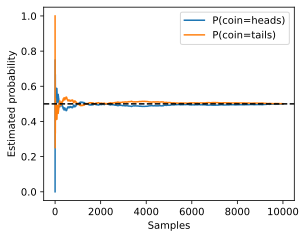

In [7]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend()

Each solid curve corresponds to one of the two values of the coin
and gives our estimated probability that the coin turns up that value
after each group of experiments.
The dashed black line gives the true underlying probability.
As we get more data by conducting more experiments,
the curves converge towards the true probability.
You might already begin to see the shape
of some of the more advanced questions
that preoccupy statisticians:
How quickly does this convergence happen?
If we had already tested many coins
manufactured at the same plant,
how might we incorporate this information?